In [ ]:
'''
 1. Open Price
 Stock price when market opens
 Used to show starting price of the day

 2. High Price
 Highest stock price of the day
 Used to identify maximum price reached

 3. Low Price
 Lowest stock price of the day
 Used to identify minimum price reached

 4. Close Price
 Final stock price when market closes
 Most important value in stock analysis

 5. Volume
 Number of shares traded in one day
 Used to measure trading activity

 6. Time Series Data
 Data collected sequentially over time
 Used to analyze temporal patterns

 7. Trend
 General direction of stock movement
 Used to identify market growth or decline

 8. Moving Average
 Average stock price over a time period
 Used to smooth fluctuations and detect trend

 9. Volatility
 Degree of stock price fluctuations
 Used to measure market risk

 10. Daily Return
 Percentage change in stock price daily
 Used to calculate profit or loss

 11. Rolling Window
 Uses previous data points for calculations
 Used in moving average and volatility

 12. Stationary Data
 Data with constant mean and variance
 Important for forecasting models

 13. Non-Stationary Data
 Data whose patterns change over time
 Common in stock market prices

 14. ADF Test
 Statistical test for stationarity
 Used to check forecasting suitability

 15. p-value
 Probability value from statistical test
 Used to determine stationarity result

 16. Seasonal Decomposition
 Separates time series into components
 Used to identify hidden patterns

 17. Trend Component
 Long-term movement in stock prices
 Used to observe overall direction

 18. Seasonal Component
 Repeating patterns over time
 Used to detect cyclic behavior

 19. Residual Component
 Random noise after decomposition
 Used to identify unpredictable variations '''

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2021-01-04  125.856712  129.941387  123.279474  129.853862  143301900
2021-01-05  127.412743  128.122709  124.903582  125.350958   97664900
2021-01-06  123.123856  127.451673  122.909895  124.213106  155088000
2021-01-07  127.325249  128.015760  124.349271  124.835543  109578200
2021-01-08  128.424194  128.988271  126.654160  128.793750  105158200
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1255 entries, 2021-01-04 to 2025-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1255 non-null   float64
 1   (High, AAPL)    1255 non-null   float64
 2   (Low, AAPL)     1255 non-null   float64
 3   (Open, AAPL)    1255 non-null   float64
 4   (Volume, AAPL)  1255 non-null   int64  
d

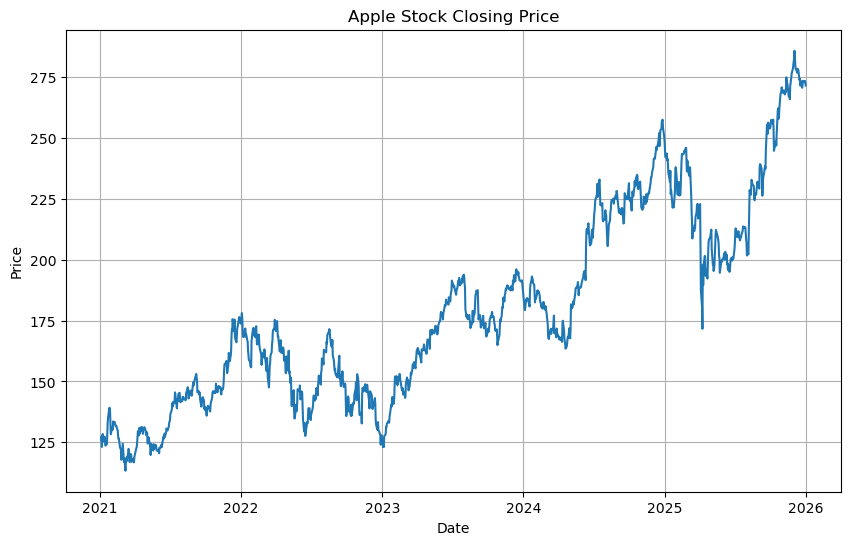

Price            Close MA_30
Ticker            AAPL      
Date                        
2021-01-04  125.856712   NaN
2021-01-05  127.412743   NaN
2021-01-06  123.123856   NaN
2021-01-07  127.325249   NaN
2021-01-08  128.424194   NaN


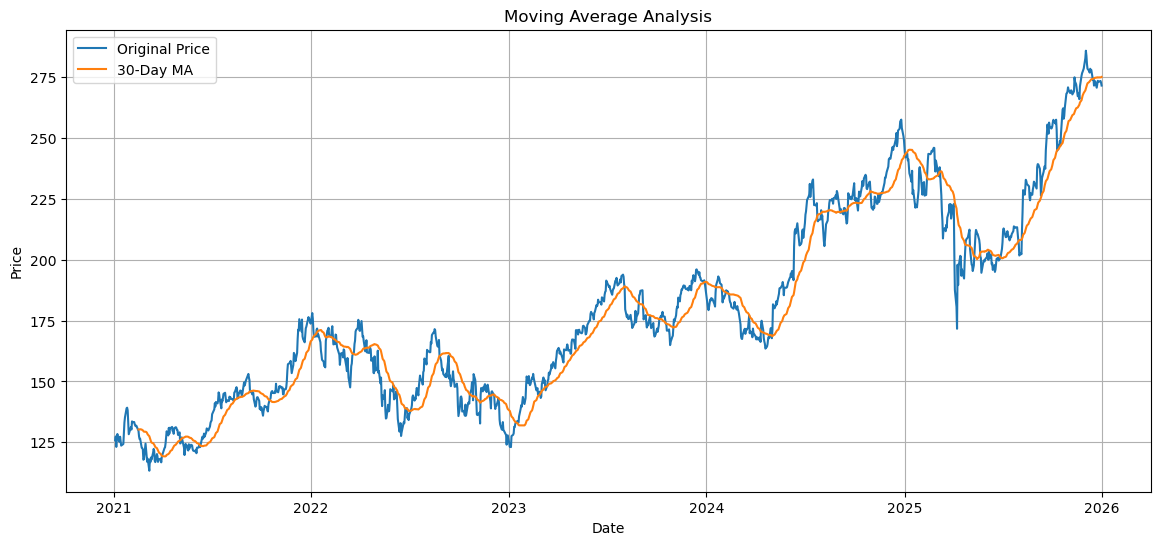

Price            Close MA_30 Volatility
Ticker            AAPL                 
Date                                   
2021-01-04  125.856712   NaN        NaN
2021-01-05  127.412743   NaN        NaN
2021-01-06  123.123856   NaN        NaN
2021-01-07  127.325249   NaN        NaN
2021-01-08  128.424194   NaN        NaN


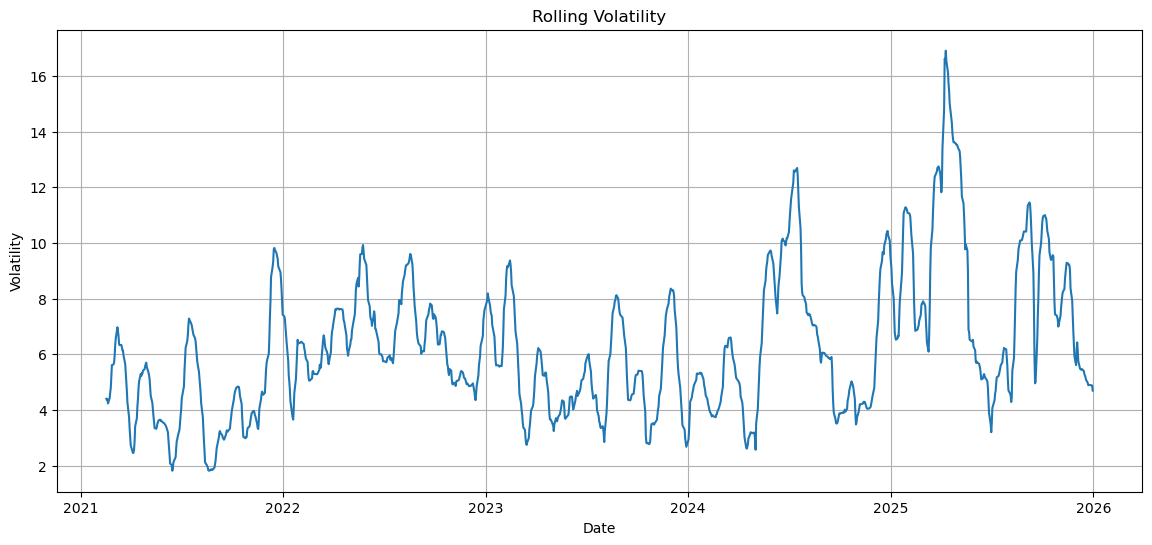

Price            Close MA_30 Volatility Daily_Return
Ticker            AAPL                              
Date                                                
2021-01-04  125.856712   NaN        NaN          NaN
2021-01-05  127.412743   NaN        NaN     0.012364
2021-01-06  123.123856   NaN        NaN    -0.033661
2021-01-07  127.325249   NaN        NaN     0.034123
2021-01-08  128.424194   NaN        NaN     0.008631


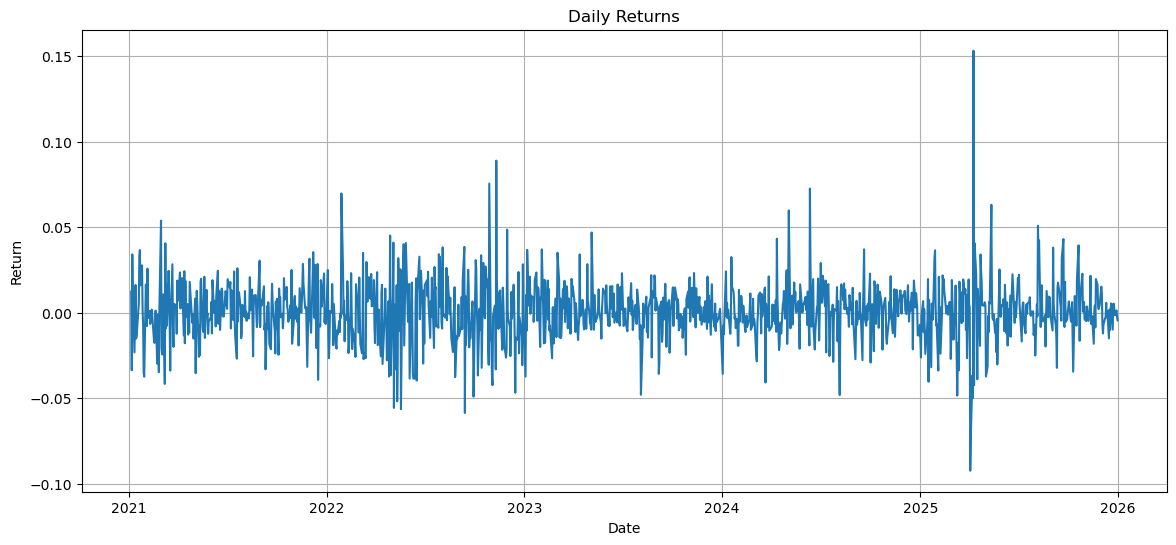

ADF Statistic : -0.7872579766673712
p-value : 0.8228363170026416
Data is Non-Stationary


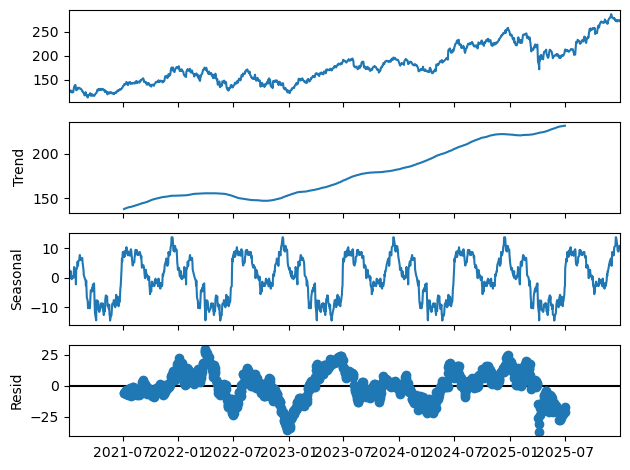

Time series analysis identifies trends and patterns.
Moving average shows long-term direction.
Volatility measures market risk.
ADF test checks stationarity.
Decomposition separates trend and seasonality.


In [5]:
# STOCK MARKET TIME SERIES ANALYSIS

# Import libraries for analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import time series functions
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# Import stock data API
import yfinance as yf

# STEP 1 : DOWNLOAD STOCK DATA
# Explanation : Load Apple stock market data
# Reason : Real data is needed for analysis

df = yf.download(
    "AAPL",
    start="2021-01-01",
    end="2026-01-01"
)

print(df.head())

# STEP 2 : CHECK DATA INFORMATION
# Explanation : View dataset structure
# Reason : Understand rows, columns, and types

print(df.info())

print(df.describe())


# STEP 3 : SELECT CLOSING PRICE
# Explanation : Use daily closing stock price
# Reason : Closing price is important in finance

data = df[['Close']]

print(data.head())


# STEP 4 : PLOT STOCK PRICE
# Explanation : Visualize stock trend
# Reason : Helps identify market movement

plt.figure(figsize=(10,6))
plt.plot(data['Close'])
plt.title("Apple Stock Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.show()


# STEP 5 : MOVING AVERAGE
# Explanation : Calculate average stock trend
# Reason : Reduces short-term fluctuations

# Create separate dataframe copy
data = df[['Close']].copy()

# Calculate moving average
data['MA_30'] = data['Close'].rolling(window=30).mean()

print(data.head(5))

# STEP 6 : PLOT MOVING AVERAGE
# Explanation : Compare price with trend line
# Reason : Helps identify uptrend and downtrend

plt.figure(figsize=(14,6))
plt.plot(data['Close'], label='Original Price')
plt.plot(data['MA_30'], label='30-Day MA')

plt.title("Moving Average Analysis")

plt.xlabel("Date")

plt.ylabel("Price")

plt.legend()

plt.grid(True)

plt.show()


# STEP 7 : CALCULATE VOLATILITY
# Explanation : Measure price fluctuations
# Reason : Detect market risk and instability

data['Volatility'] = data['Close'].rolling(window=30).std()

print(data.head())


# STEP 8 : PLOT VOLATILITY
# Explanation : Visualize market instability
# Reason : High volatility means high risk

plt.figure(figsize=(14,6))
plt.plot(data['Volatility'])
plt.title("Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.grid(True)
plt.show()

# STEP 9 : DAILY RETURNS
# Explanation : Calculate daily percentage change
# Reason : Analyze profit and loss changes

data['Daily_Return'] = data['Close'].pct_change()

print(data.head())

# STEP 10 : PLOT DAILY RETURNS
# Explanation : Show return fluctuations
# Reason : Detect sudden market changes

plt.figure(figsize=(14,6))
plt.plot(data['Daily_Return'])
plt.title("Daily Returns")
plt.xlabel("Date")
plt.ylabel("Return")
plt.grid(True)
plt.show()

# STEP 11 : ADF TEST
# Explanation : Test stationarity of data
# Reason : Important for forecasting models

clean_data = data['Close'].dropna()
result = adfuller(clean_data)
print("ADF Statistic :", result[0])
print("p-value :", result[1])

if result[1] < 0.05:
    print("Data is Stationary")
else:
    print("Data is Non-Stationary")


# STEP 12 : TIME SERIES DECOMPOSITION
# Explanation : Separate trend and seasonality
# Reason : Understand hidden temporal patterns

decomposition = seasonal_decompose(
    data['Close'],
    model='additive',
    period=252
)

'''
Python creates an object containing:

decomposition.observed
decomposition.trend
decomposition.seasonal
decomposition.resid 

'''

decomposition.plot()

'''
internally this decomposition.plot() performs something similar to:
fig, axes = plt.subplots(4, 1)

# Original graph
axes[0].plot(decomposition.observed)

# Trend graph
axes[1].plot(decomposition.trend)

# Seasonal graph
axes[2].plot(decomposition.seasonal)

# Residual graph
axes[3].plot(decomposition.resid)

'''

plt.show()


# STEP 13 : FINAL CONCLUSION
# Explanation : Summarize analysis results
# Reason : Understand overall market behavior

print("Time series analysis identifies trends and patterns.")
print("Moving average shows long-term direction.")
print("Volatility measures market risk.")
print("ADF test checks stationarity.")
print("Decomposition separates trend and seasonality.")

In [2]:
!pip install yfinance

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   -------------------------------